In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pathlib import Path

In [18]:
PROJECT_ROOT = Path("..")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

In [19]:
TICKERS = [
    "AAPL", "MSFT", "NVDA", "AMZN", "META",
    "GOOGL", "TSLA", "JPM", "V", "UNH",
    "MA", "HD", "PG", "XOM", "LLY",
    "AVGO", "COST", "ABBV", "KO", "PEP",
    "MRK", "BAC", "WMT", "ADBE", "CRM",
    "NFLX", "AMD", "INTC", "CSCO", "ORCL"
]

START_DATE = "2015-01-01"
END_DATE = "2025-01-01"

In [20]:
raw = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

raw.head()

[*********************100%***********************]  30 of 30 completed


Price           Close                                                 \
Ticker           AAPL       ABBV       ADBE   AMD     AMZN      AVGO   
Date                                                                   
2015-01-02  24.192606  41.411922  72.339996  2.67  15.4260  7.544512   
2015-01-05  23.511055  40.632576  71.980003  2.66  15.1095  7.423907   
2015-01-06  23.513271  40.431461  70.529999  2.63  14.7645  7.255063   
2015-01-07  23.842983  42.065552  71.110001  2.58  14.9210  7.451047   
2015-01-08  24.759081  42.505501  72.919998  2.61  15.0230  7.823408   

Price                                                    ...     Volume  \
Ticker            BAC        COST        CRM       CSCO  ...       NFLX   
Date                                                     ...              
2015-01-02  14.123797  113.815193  58.382847  19.603922  ...  134750000   
2015-01-05  13.713499  112.521141  57.328327  19.213396  ...  181650000   
2015-01-06  13.303200  114.008034  56.372368  19.206295  ...  160377000   
2015-01-07  13.366323  115.993240  56.106270  19.383802  ...   98497000   
2015-01-08  13.642488  116.989883  57.742249  19.532906  ...   96019000   

Price                                                                 \
Ticker           NVDA      ORCL      PEP       PG      TSLA      UNH   
Date                                                                   
2015-01-02  113680000  15070200  3545700  7251400  71466000  3060900   
2015-01-05  197952000  18369400  6441000  8626100  80527500  4679000   
2015-01-06  197764000  19229500  6195000  7791200  93928500  3468300   
2015-01-07  321808000  13502200  6526300  5986600  44526000  3225800   
2015-01-08  283780000  17516900  7131600  6823300  51637500  5346100   

Price                                     
Ticker             V       WMT       XOM  
Date                                      
2015-01-02   8389600  13505400  10220400  
2015-01-05  12751200  20937000  18502400  
2015-01-06  11070000  24615300  16670700  
2015-01-07   9346800  25495200  13590700  
2015-01-08  10443200  38140800  15487500  

[5 rows x 150 columns]

In [22]:
prices = raw["Close"].copy()

prices = prices.dropna(axis=1, how="all")
prices = prices.dropna(axis=0, how="all")

prices.head()

Ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,24.192606,41.411922,72.339996,2.67,15.4260,7.544512,14.123797,113.815193,58.382847,19.603922,...,4.984857,0.482985,37.353558,67.283440,65.555733,14.620667,83.828789,61.088104,23.127546,57.145542
2015-01-05,23.511055,40.632576,71.980003,2.66,15.1095,7.423907,13.713499,112.521141,57.328327,19.213396,...,4.731143,0.474827,36.829716,66.777618,65.244049,14.006000,82.447983,59.739658,23.060232,55.581947
2015-01-06,23.513271,40.431461,70.529999,2.63,14.7645,7.255063,13.303200,114.008034,56.372368,19.206295,...,4.650143,0.460432,36.449501,66.271759,64.946869,14.085333,82.281624,59.354702,23.237932,55.286457
2015-01-07,23.842983,42.065552,71.110001,2.58,14.9210,7.451047,13.366323,115.993240,56.106270,19.383802,...,4.674286,0.459232,36.457947,68.209656,65.287544,14.063333,83.121742,60.149960,23.854486,55.846649
2015-01-08,24.759081,42.505501,72.919998,2.61,15.0230,7.823408,13.642488,116.989883,57.742249,19.532906,...,4.778000,0.476507,36.677628,69.449295,66.034149,14.041333,87.089424,60.956715,24.357965,56.776196


In [23]:
print("prices shape:", prices.shape)
print("start:", prices.index.min())
print("end:", prices.index.max())
print("number of tickers:", len(prices.columns))
print(prices.columns.tolist())

prices shape: (2516, 30)
start: 2015-01-02 00:00:00
end: 2024-12-31 00:00:00
number of tickers: 30
['AAPL', 'ABBV', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'BAC', 'COST', 'CRM', 'CSCO', 'GOOGL', 'HD', 'INTC', 'JPM', 'KO', 'LLY', 'MA', 'META', 'MRK', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']


In [24]:
returns = prices.pct_change().dropna(how="all")

returns.head()

Ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.018819,-0.004976,-0.003745,-0.020517,-0.015986,-0.029050,-0.011370,-0.018062,-0.019921,...,-0.050897,-0.016891,-0.014024,-0.007518,-0.004754,-0.042041,-0.016472,-0.022074,-0.002911,-0.027362
2015-01-06,0.000094,-0.004950,-0.020145,-0.011278,-0.022833,-0.022743,-0.029919,0.013214,-0.016675,-0.000370,...,-0.017121,-0.030318,-0.010324,-0.007575,-0.004555,0.005664,-0.002018,-0.006444,0.007706,-0.005316
2015-01-07,0.014022,0.040416,0.008223,-0.019011,0.010600,0.027013,0.004745,0.017413,-0.004720,0.009242,...,0.005192,-0.002606,0.000232,0.029242,0.005245,-0.001562,0.010210,0.013398,0.026532,0.010133
2015-01-08,0.038422,0.010459,0.025453,0.011628,0.006836,0.049974,0.020661,0.008592,0.029159,0.007692,...,0.022188,0.037618,0.006026,0.018174,0.011436,-0.001564,0.047733,0.013412,0.021106,0.016645
2015-01-09,0.001073,-0.027355,-0.014811,0.007663,-0.011749,0.010695,-0.017930,-0.015389,-0.007339,0.010179,...,-0.015458,0.004028,-0.000461,-0.006771,-0.009331,-0.018802,-0.009360,-0.014823,-0.012380,-0.001409


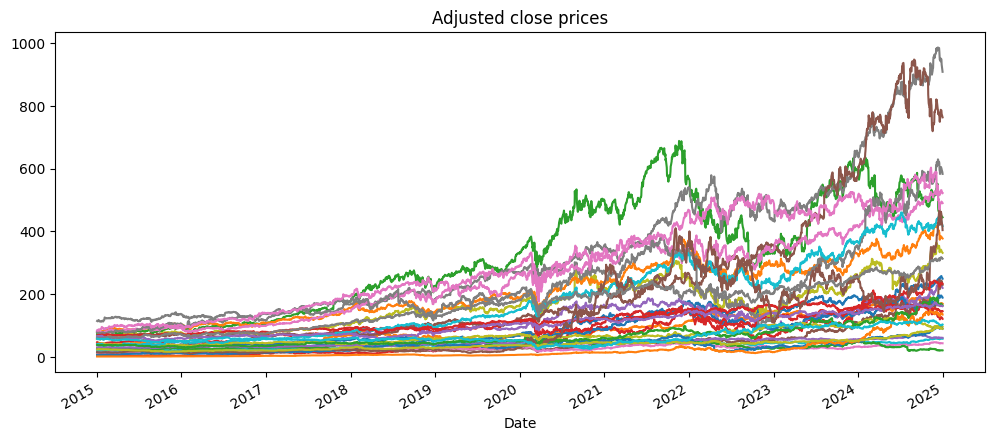

In [25]:
prices.plot(figsize=(12, 5), legend=False)
plt.title("Adjusted close prices")
plt.show()

In [26]:
returns.mean().sort_values().tail()

Ticker
NFLX    0.001530
AVGO    0.001635
TSLA    0.001966
AMD     0.002184
NVDA    0.002704
dtype: float64

In [27]:
prices.to_parquet(DATA_PROCESSED / "prices.parquet")
returns.to_parquet(DATA_PROCESSED / "returns.parquet")

In [28]:
prices_check = pd.read_parquet(DATA_PROCESSED / "prices.parquet")
returns_check = pd.read_parquet(DATA_PROCESSED / "returns.parquet")

prices_check.shape, returns_check.shape

((2516, 30), (2515, 30))

In [13]:
print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)

print("\nDate range:")
print(prices.index.min())
print(prices.index.max())

print("\nTickers:")
print(list(prices.columns))

Prices shape: (2516, 30)
Returns shape: (2515, 30)

Date range:
2015-01-02 00:00:00
2024-12-31 00:00:00

Tickers:
['AAPL', 'ABBV', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'BAC', 'COST', 'CRM', 'CSCO', 'GOOGL', 'HD', 'INTC', 'JPM', 'KO', 'LLY', 'MA', 'META', 'MRK', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PG', 'TSLA', 'UNH', 'V', 'WMT', 'XOM']


In [14]:
print(prices.isna().sum().sum())
print(returns.isna().sum().sum())

0
0
